MERGED rows: 117
PCs used: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10'] X shape: (117, 10)


,k,silhouette
0,2,0.650435
1,3,0.085810
2,4,0.213027
3,5,0.197538
4,6,0.250338
5,7,0.268326


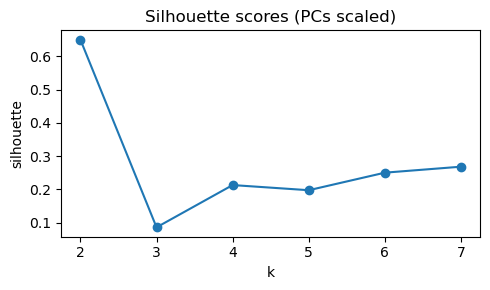

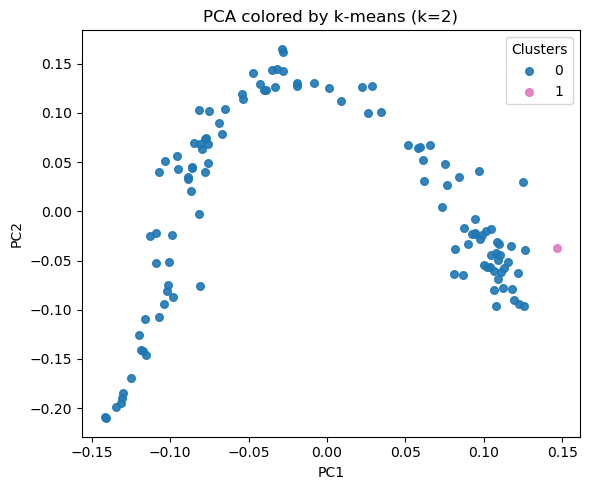

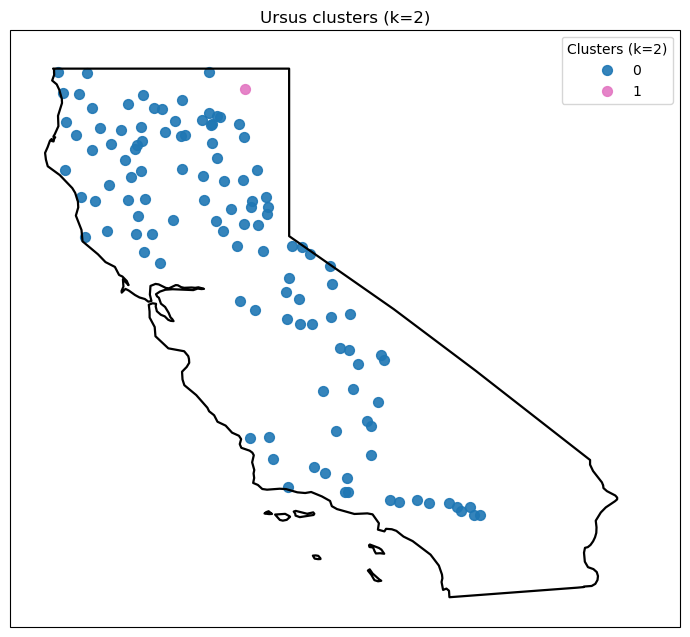

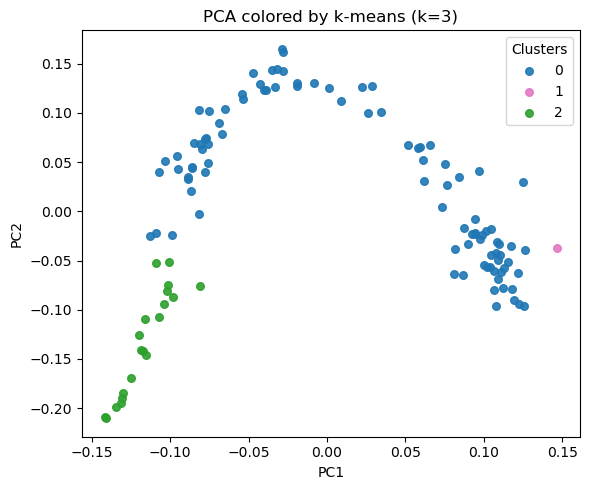

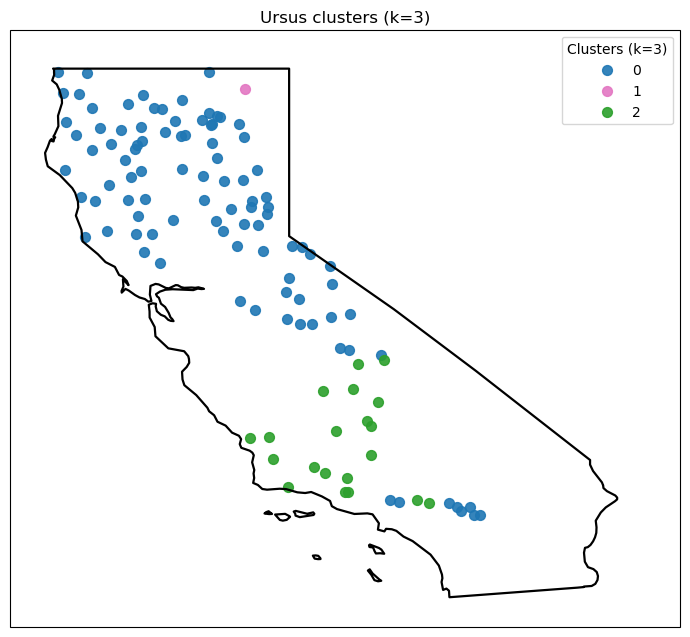

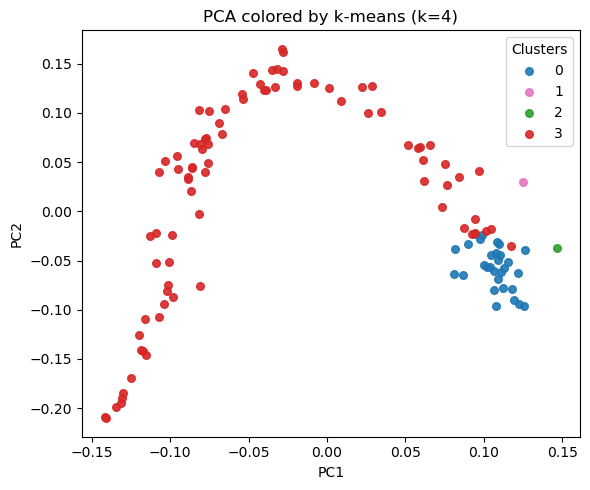

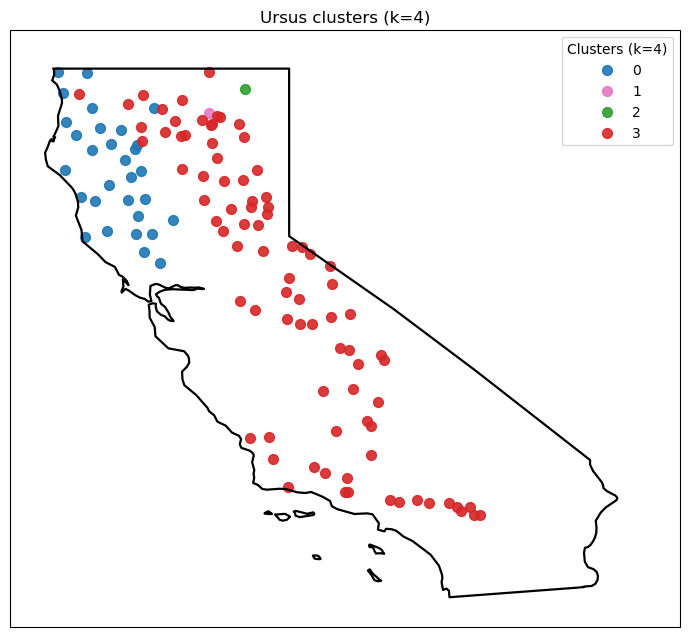

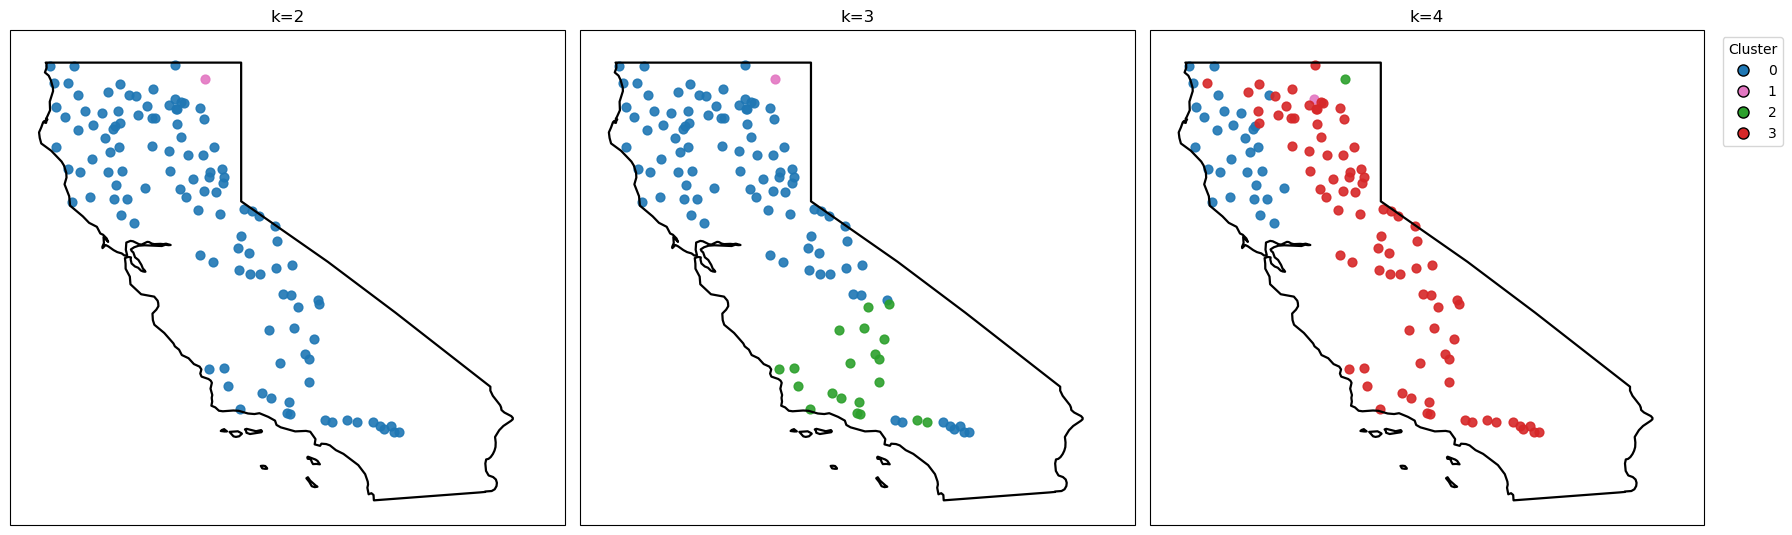

,Tested k values,PC1 variance explained,PC2 variance explained,PC3 variance explained,PC4 variance explained,PC5 variance explained
0,"2, 3, 4, 5",29.0,12.19,10.26,8.57,7.77


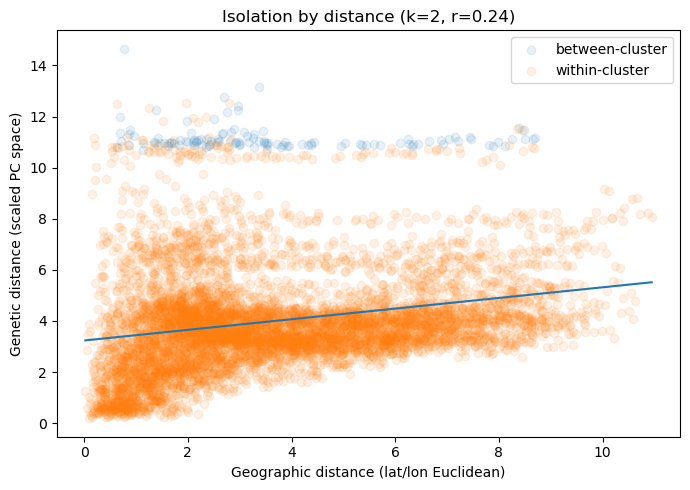

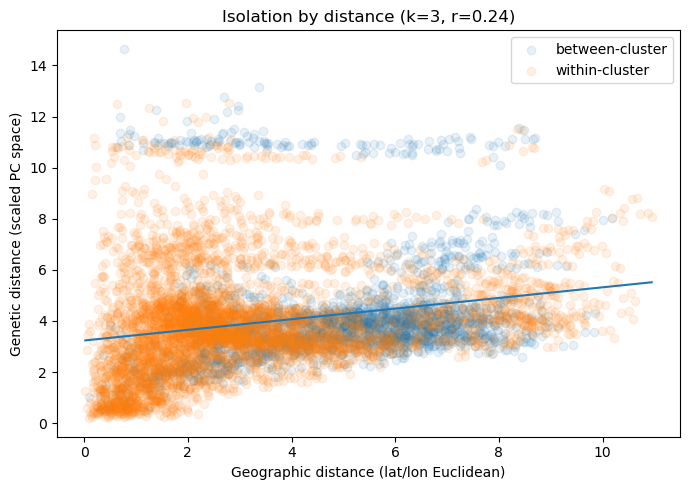

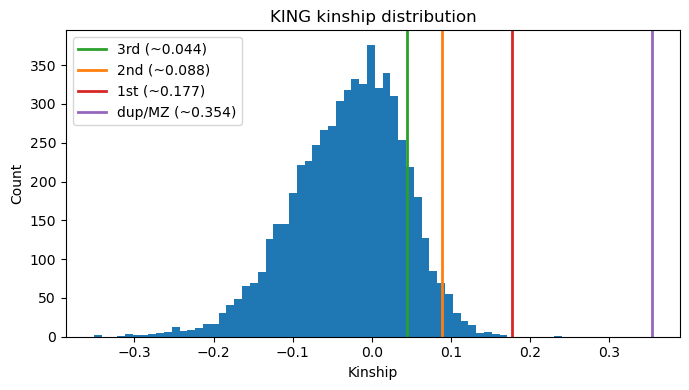

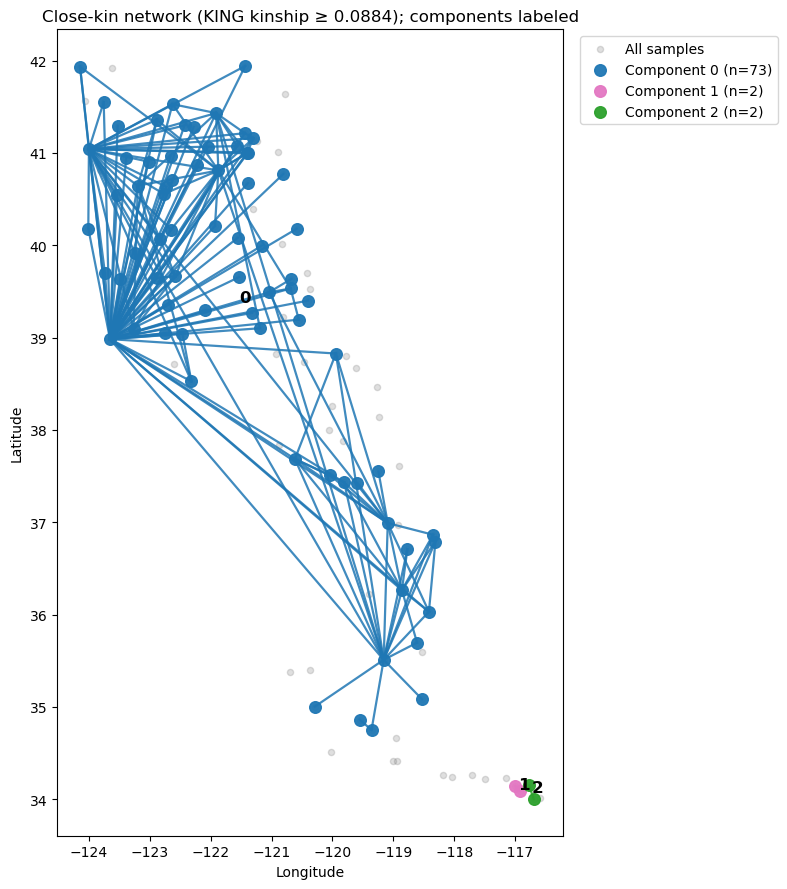

Edges: 160 Components shown: 3
Done.


In [7]:
# =========================
# FULL UPDATED CODE (single cell)
# - Uses your path style (WORKDIR/EIGENVEC/META_CSV/OUTDIR)
# - plotting_k_means-style: PC1..PC10 + StandardScaler + KMeans
# - k = 2, 3, 4 outputs (PCA + CA maps + 3-panel comparison)
# - Consistent cluster colors across ALL plots:
#     0=blue, 1=pink, 2=green, 4=brown (and sensible defaults for others)
# - Stable cluster numbering (relabels k-means by mean longitude west->east)
# - KING kinship histogram with COLORED cutoff lines
# - Close-kin network (THR=0.15) with component coloring
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from scipy.spatial.distance import pdist, squareform
import networkx as nx

import cartopy.crs as ccrs
from cartopy.io import shapereader

# -------------------------
# PATHS (as requested)
# -------------------------
WORKDIR  = "/Users/isabelmikheev/Desktop/Bioinformatics"
EIGENVEC = os.path.join(WORKDIR, "ursus_pca.eigenvec")
META_CSV = os.path.join(WORKDIR, "59-Ursus_workflow.csv")
OUTDIR   = os.path.join(WORKDIR, "plots")
os.makedirs(OUTDIR, exist_ok=True)

KING_KIN = os.path.join(WORKDIR, "59-Ursus_king.kin")

# -------------------------
# FIXED, CONSISTENT COLORS
# -------------------------
CLUSTER_COLORS = {
    0: "#1f77b4",  # blue
    1: "#e377c2",  # pink
    2: "#2ca02c",  # green
    3: "#d62728",  # red (fallback if k=4)
    4: "#8c564b",  # brown
    5: "#9467bd",  # purple
    6: "#ff7f0e",  # orange
    7: "#17becf",  # teal
}
def color_for_cluster(c: int) -> str:
    return CLUSTER_COLORS.get(int(c), "#7f7f7f")  # gray fallback

# -------------------------
# CA outline (Cartopy Natural Earth)
# -------------------------
CA_EXTENT = [-125.0, -113.0, 32.0, 42.7]

def add_ca_outline(ax):
    shp = shapereader.natural_earth(resolution="50m", category="cultural",
                                    name="admin_1_states_provinces")
    reader = shapereader.Reader(shp)
    for rec in reader.records():
        if rec.attributes.get("name") == "California" and rec.attributes.get("admin") == "United States of America":
            ax.add_geometries([rec.geometry], crs=ccrs.PlateCarree(),
                              facecolor="none", edgecolor="black", linewidth=1.6)
            break

# -------------------------
# Load PCA eigenvec (headerless: FID IID PC1 PC2 ...)
# -------------------------
pca = pd.read_csv(EIGENVEC, sep=r"\s+", header=None, engine="python")
ncols = pca.shape[1]
pca.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, ncols - 1)]
pca["IID"] = pca["IID"].astype(str).str.strip()

# -------------------------
# Load metadata + dedupe to one row per BioSample
# -------------------------
meta = pd.read_csv(META_CSV)
meta["BioSample"] = meta["BioSample"].astype(str).str.strip()
meta = meta.dropna(subset=["lat", "long"]).copy()
meta = meta.sort_values("BioSample").drop_duplicates(subset=["BioSample"], keep="first")

meta["lat"]  = pd.to_numeric(meta["lat"], errors="coerce")
meta["long"] = pd.to_numeric(meta["long"], errors="coerce")
meta = meta.dropna(subset=["lat", "long"]).copy()

merged = pca.merge(meta, left_on="IID", right_on="BioSample", how="inner")
print("MERGED rows:", len(merged))

# -------------------------
# Features: PC1..PC10 + scaling (plotting_k_means style)
# IMPORTANT: force PC columns numeric to avoid the "diagonal categorical" bug.
# -------------------------
pcs = [f"PC{i}" for i in range(1, 11)]
pcs = [c for c in pcs if c in merged.columns]  # in case fewer PCs exist

for c in pcs:
    merged[c] = pd.to_numeric(merged[c], errors="coerce")
merged = merged.dropna(subset=["PC1", "PC2"]).copy()

X_raw = merged[pcs].to_numpy()
X = StandardScaler().fit_transform(X_raw)
print("PCs used:", pcs, "X shape:", X.shape)

# -------------------------
# Stable relabeling: west->east by mean longitude
# -------------------------
def relabel_by_mean_lon(tmp_df, labels):
    tmp2 = tmp_df.copy()
    tmp2["group"] = labels
    order = tmp2.groupby("group")["long"].mean().sort_values().index.tolist()
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[x] for x in labels])

# -------------------------
# Silhouette (k=2..7)
# -------------------------
sil = {}
for k_test in range(2, 8):
    km = KMeans(n_clusters=k_test, random_state=0, n_init=50)
    labs = km.fit_predict(X)
    sil[k_test] = float(silhouette_score(X, labs))

sil_df = pd.DataFrame({"k": list(sil.keys()), "silhouette": list(sil.values())}).sort_values("k")
display(sil_df)

plt.figure(figsize=(5,3))
plt.plot(sil_df["k"], sil_df["silhouette"], marker="o")
plt.title("Silhouette scores (PCs scaled)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.tight_layout()
plt.show()

# -------------------------
# Plot PCA (PC1 vs PC2) + CA map for a given k
# -------------------------
def plot_pca_and_map_for_k(k):
    km = KMeans(n_clusters=k, random_state=0, n_init=50)
    labels = km.fit_predict(X)

    tmp = merged.copy()
    labels = relabel_by_mean_lon(tmp, labels)  # stable numbering
    tmp["group"] = labels

    # PCA plot
    plt.figure(figsize=(6,5))
    for g in range(k):
        sub = tmp[tmp["group"] == g]
        plt.scatter(sub["PC1"].to_numpy(), sub["PC2"].to_numpy(),
                    s=30, alpha=0.9, color=color_for_cluster(g), label=str(g))
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.title(f"PCA colored by k-means (k={k})")
    plt.legend(title="Clusters", loc="best")
    plt.tight_layout()
    plt.show()

    # CA map (Cartopy)
    fig = plt.figure(figsize=(7,9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(CA_EXTENT, crs=ccrs.PlateCarree())
    add_ca_outline(ax)

    for g in range(k):
        sub = tmp[tmp["group"] == g]
        ax.scatter(sub["long"], sub["lat"],
                   s=50, alpha=0.9, color=color_for_cluster(g),
                   label=str(g), transform=ccrs.PlateCarree())

    ax.legend(title=f"Clusters (k={k})", loc="upper right")
    ax.set_title(f"Ursus clusters (k={k})")
    plt.tight_layout()
    plt.show()

    return labels

# -------------------------
# k = 2, 3, 4
# -------------------------
labels2 = plot_pca_and_map_for_k(2)
labels3 = plot_pca_and_map_for_k(3)
labels4 = plot_pca_and_map_for_k(4)

# -------------------------
# Three-panel CA comparison (k=2/3/4) with consistent colors
# -------------------------
def three_maps(labels2, labels3, labels4):
    fig = plt.figure(figsize=(18,7))
    axs = [
        plt.subplot(1, 3, 1, projection=ccrs.PlateCarree()),
        plt.subplot(1, 3, 2, projection=ccrs.PlateCarree()),
        plt.subplot(1, 3, 3, projection=ccrs.PlateCarree()),
    ]

    for ax, labs, k, title in zip(
        axs,
        [labels2, labels3, labels4],
        [2, 3, 4],
        ["k=2", "k=3", "k=4"]
    ):
        tmp = merged.copy()
        tmp["group"] = labs
        ax.set_extent(CA_EXTENT, crs=ccrs.PlateCarree())
        add_ca_outline(ax)

        for g in range(k):
            sub = tmp[tmp["group"] == g]
            ax.scatter(sub["long"], sub["lat"],
                       s=40, alpha=0.9, color=color_for_cluster(g),
                       transform=ccrs.PlateCarree())

        ax.set_title(title)

    # legend on last axis
    handles = [plt.Line2D([0],[0], marker="o", color="w",
                          markerfacecolor=color_for_cluster(g),
                          markeredgecolor="black", markersize=8, label=str(g))
               for g in range(4)]
    axs[-1].legend(handles=handles, title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

three_maps(labels2, labels3, labels4)

# -------------------------
# tested k’s + % variance explained for PCs 1–5
# -------------------------

EIGENVAL = os.path.join(WORKDIR, "ursus_pca.eigenval")  # same WORKDIR style
eig = np.loadtxt(EIGENVAL)
pct = 100 * eig / eig.sum()

tested_ks = [2, 3, 4, 5]
pc_rows = {f"PC{i} variance explained": round(float(pct[i-1]), 2) for i in range(1, 6)}

summary = {
    "Tested k values": ", ".join(map(str, tested_ks)),
    **pc_rows
}

table = pd.DataFrame([summary])
display(table)

# -------------------------
# Isolation-by-distance (within/between = k=4)
# -------------------------
genD = squareform(pdist(X, metric="euclidean"))                 # genetic distance in scaled PC space
geo = merged[["lat","long"]].to_numpy()
geoD = squareform(pdist(geo, metric="euclidean"))               # geographic distance in lat/lon space
iu = np.triu_indices_from(genD, k=1)

def plot_ibd(labels, k_label):
    x = geoD[iu]
    y = genD[iu]
    same = (labels[iu[0]] == labels[iu[1]])

    m, b = np.polyfit(x, y, 1)
    r = np.corrcoef(x, y)[0, 1]

    plt.figure(figsize=(7,5))
    plt.scatter(x[~same], y[~same], alpha=0.10, label="between-cluster")
    plt.scatter(x[same],  y[same],  alpha=0.10, label="within-cluster")
    xx = np.linspace(x.min(), x.max(), 200)
    plt.plot(xx, m*xx + b)
    plt.xlabel("Geographic distance (lat/lon Euclidean)")
    plt.ylabel("Genetic distance (scaled PC space)")
    plt.title(f"Isolation by distance (k={k_label}, r={r:.2f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_ibd(labels2, 2)
plot_ibd(labels3, 3)

# -------------------------
# KING kinship histogram with COLORED vertical lines
# -------------------------
kin = pd.read_csv(KING_KIN, sep=r"\s+", engine="python")
kin["Kinship"] = pd.to_numeric(kin["Kinship"], errors="coerce")

plt.figure(figsize=(7,4))
plt.hist(kin["Kinship"].dropna(), bins=60)
# colored thresholds
thresholds = [
    (0.0442, "3rd (~0.044)", "#2ca02c"),  # green
    (0.0884, "2nd (~0.088)", "#ff7f0e"),  # orange
    (0.1770, "1st (~0.177)", "#d62728"),  # red
    (0.3540, "dup/MZ (~0.354)", "#9467bd") # purple
]
for t, lab, col in thresholds:
    plt.axvline(t, color=col, linewidth=2, label=lab)

plt.title("KING kinship distribution")
plt.xlabel("Kinship")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Close-kin network (slide-friendly): THR=0.15 components labeled
# Uses component colors cycling through your palette
# -------------------------
THR = 0.0884
pos = dict(zip(merged["IID"].astype(str), zip(merged["long"], merged["lat"])))

edges = kin.loc[kin["Kinship"] >= THR, ["ID1","ID2"]].dropna()
G = nx.Graph()
for a,b in edges.to_numpy():
    a,b = str(a), str(b)
    if a in pos and b in pos:
        G.add_edge(a,b)

comps = sorted(nx.connected_components(G), key=len, reverse=True)

plt.figure(figsize=(8,9))
plt.scatter(merged["long"], merged["lat"], s=20, alpha=0.25, color="gray", label="All samples")

comp_id = 0
for comp in comps:
    if len(comp) < 2:
        continue
    nodes = list(comp)
    H = G.subgraph(nodes)

    comp_color = color_for_cluster(comp_id)  # reuse palette for component colors

    # edges
    for a,b in H.edges():
        x0,y0 = pos[a]; x1,y1 = pos[b]
        plt.plot([x0,x1],[y0,y1], linewidth=1.6, alpha=0.85, color=comp_color)

    # nodes
    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    plt.scatter(xs, ys, s=70, alpha=0.95, color=comp_color,
                label=f"Component {comp_id} (n={len(nodes)})")

    # label component id at centroid
    plt.text(np.mean(xs), np.mean(ys), str(comp_id), fontsize=12, fontweight="bold")
    comp_id += 1

plt.title(f"Close-kin network (KING kinship ≥ {THR}); components labeled")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Edges:", G.number_of_edges(), "Components shown:", comp_id)
print("Done.")